# Extreme Value Analysis

Please refer to the following link for the theory on this topic.

https://tudelft-citg.github.io/HOS-prob-design/intro.html

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import plotly.graph_objects as go
import itertools
from scipy.signal import find_peaks
from matplotlib import pyplot as plt
from matplotlib.legend_handler import HandlerLine2D

%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6

- Establish the Peak Over Threshold values.
- Starting point is Hs data in file hsarras=ys POT test.csv with 3 hour Hs data
- Here the Thershold (thresh) is chosen $H_s = 2.5 m$ and the time is 4 (j) * 3 hrs = 12 hrs
- Peaks delivers the POT values over which one should do the Weibull or Gumbel fit

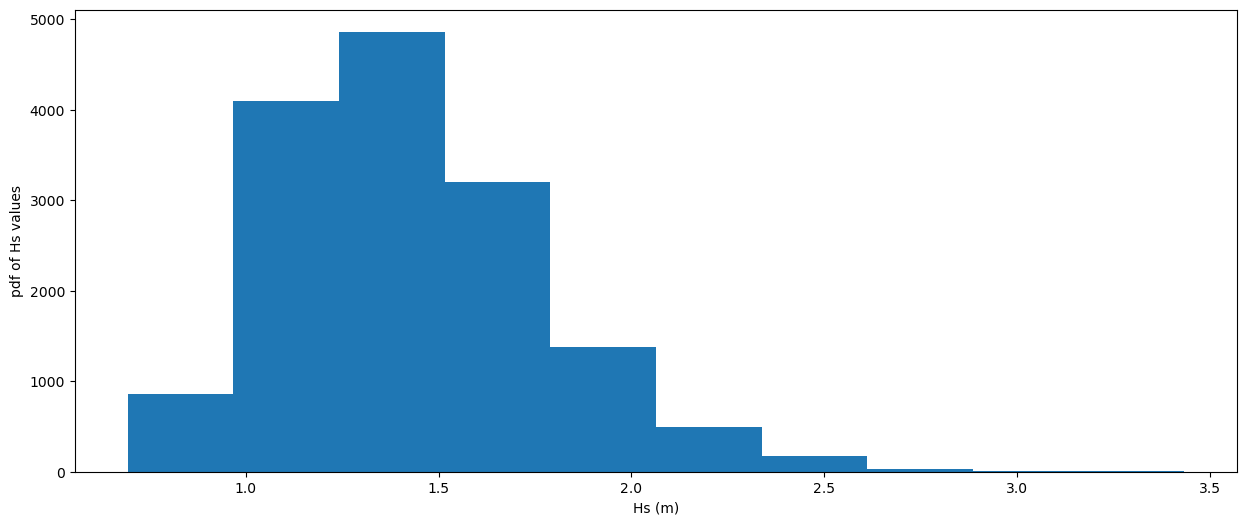

Number of Hs values:  15099



In [2]:
wave_data = pd.read_csv('hsarrays.csv')
time_series = wave_data['Hs']
# 
#  Extract Hs from database and plot histogram
#

fig, ax = plt.subplots(1, 1)
plt.xlabel('Hs (m)')
plt.ylabel('pdf of Hs values')
ax.hist(time_series, histtype='stepfilled')
plt.show()

#
imax = len(time_series)
print('Number of Hs values: ',imax)
print()
dft = wave_data.get("time")
pass

## Peak over threshold

In [3]:
#
# Peak Over Through code
def pot_method(data, threshold, dtime):
    idx_pot, _ = find_peaks(data, height = threshold, distance = dtime)
    pot_list = data.loc[idx_pot]
    return idx_pot, pot_list
#

In [4]:
fig = go.Figure(data=go.Scatter(
    y = time_series,
    mode = 'lines'
))

fig.show()

In [5]:
#
# threshold is the Hs threshold value
# dtime is the number of values used in time (here 4 * 3 hour samples = 12 hrs)
#
threshold = 2.2
dtime = 4
tare = threshold

indices,pot_maxima = pot_method(time_series, threshold, dtime)

kmax = len(pot_maxima)
print("Number of peaks based on Threshold: ",threshold," and time ",dtime," is ",kmax)
print('Last part of the calculated Peaks over Threshold values: ')
print(pot_maxima.tail())

Number of peaks based on Threshold:  2.2  and time  4  is  118
Last part of the calculated Peaks over Threshold values: 
13987    2.517089
14019    2.426647
14107    2.509584
14390    2.262145
14859    2.257381
Name: Hs, dtype: float64


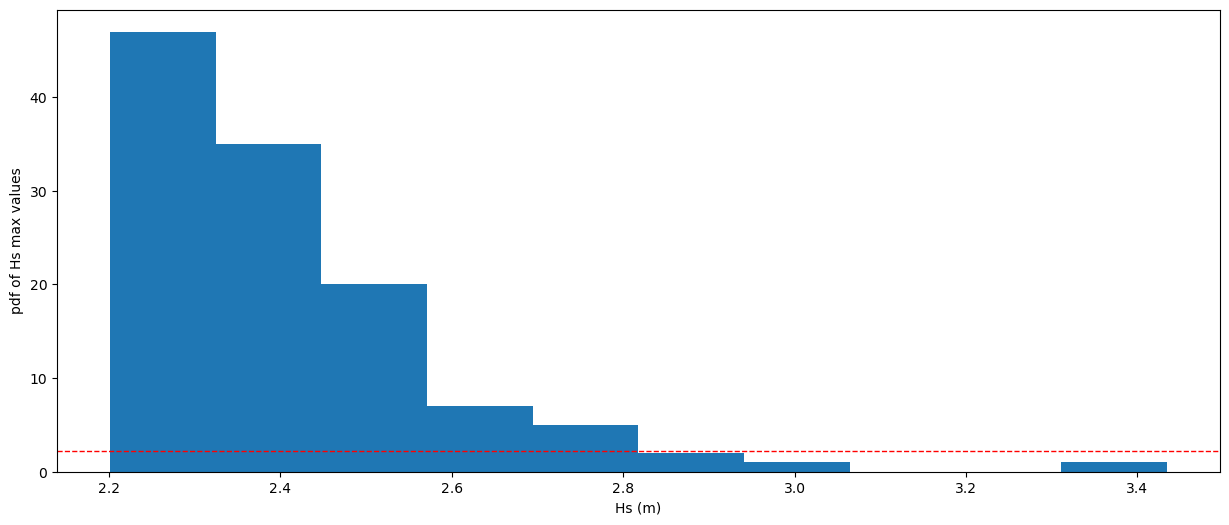

In [ ]:
#
#
# following is a subsegment to extract part of the data for visualization
# NB: j is starting value op peaks and range is number of points to be visualized
#
sub_ind = []
j = 0
for i in range(0,24):
    k = j + i
    val = indices[k]
    sub_ind.append(val)
#
sub_pot = pot_maxima.loc[sub_ind]

#
# Update numbers based on range!
#
inst = sub_ind[0]
inen = sub_ind[23]
sub_tim = time_series[inst:inen]
sub_pos = list(itertools.chain(range(inst, inen)))
#
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=sub_pos,y=sub_tim,
    mode='lines',
    name='Original Plot'
))

#
#
fig.add_trace(go.Scatter(
    x=sub_ind,y=sub_pot,
    mode='markers',
    marker=dict(
        size=8,
        color='red',
        symbol='cross'
    ),
    name='Detected Peaks'
))

fig.show()

#
pot_time = []
for i in range(0,kmax):
    val = indices[i]
    pot_time.append(dft[val])
#
fig, ax = plt.subplots(1, 1)
plt.xlabel('Hs (m)')
plt.ylabel('pdf of Hs max values')
ax.hist(pot_maxima, histtype='stepfilled')
plt.show()
#
pass

In [7]:
array = np.array([indices, 
         pot_time,
         pot_maxima])

array = array.T

df = pd.DataFrame(array, columns=['index', 'pot_time', 'pot_maxima'])

df.to_csv('EVA result POT extremes.csv', index=False)


## Extreme value distributions

In [8]:
import reliability.Fitters as rf

Tare the values of wave height against the threshold before fitting the distribution

In [9]:
dfmax = []
for it in pot_maxima.items():
    val = it[1] - tare # pot_maxima[i]
    dfmax.append(val)    
dfmax.sort()

### Fit Weibull 2P

Results from Fit_Weibull_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 118/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
    Alpha        0.218649       0.0186226  0.185034  0.258372
     Beta         1.13646       0.0810278  0.988241    1.3069 

Goodness of fit    Value
 Log-likelihood   68.262
           AICc  -132.42
            BIC -126.983
             AD 0.500522 



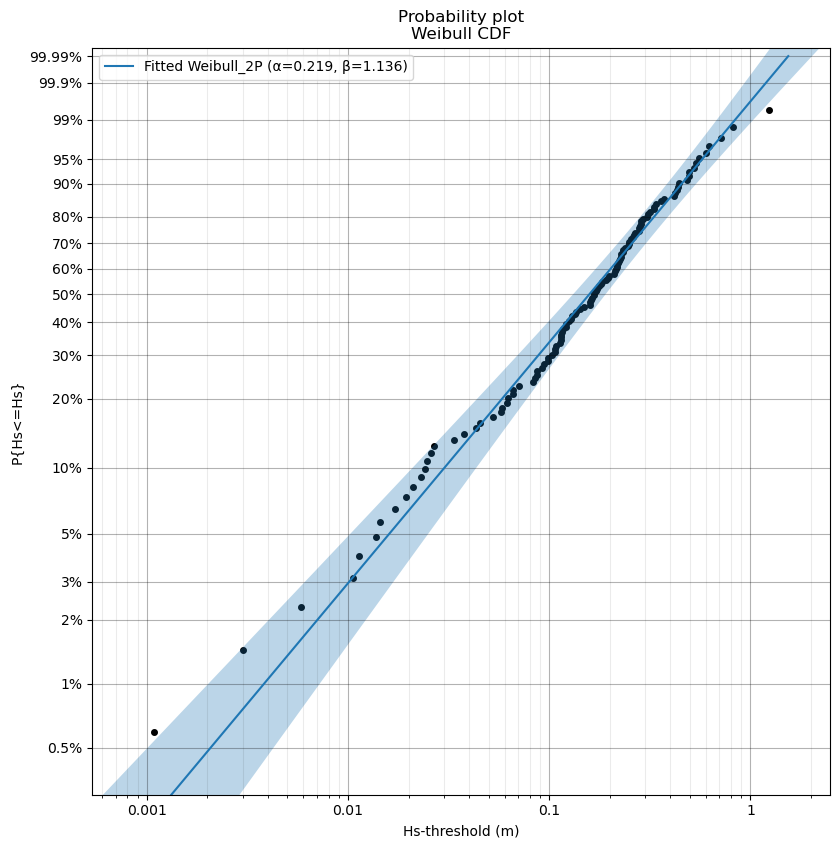

In [10]:
waw2 = rf.Fit_Weibull_2P(failures=dfmax)
plt.ylabel('P{Hs<=Hs}')
plt.xlabel('Hs-threshold (m)')
plt.show()

### Fit Weibull 3P

Results from Fit_Weibull_3P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 118/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
    Alpha        0.218649       0.0186226  0.185034  0.258372
     Beta         1.13646       0.0810278  0.988241    1.3069
    Gamma               0               0         0         0 

Goodness of fit    Value
 Log-likelihood   68.262
           AICc -130.314
            BIC -122.212
             AD 0.500522 



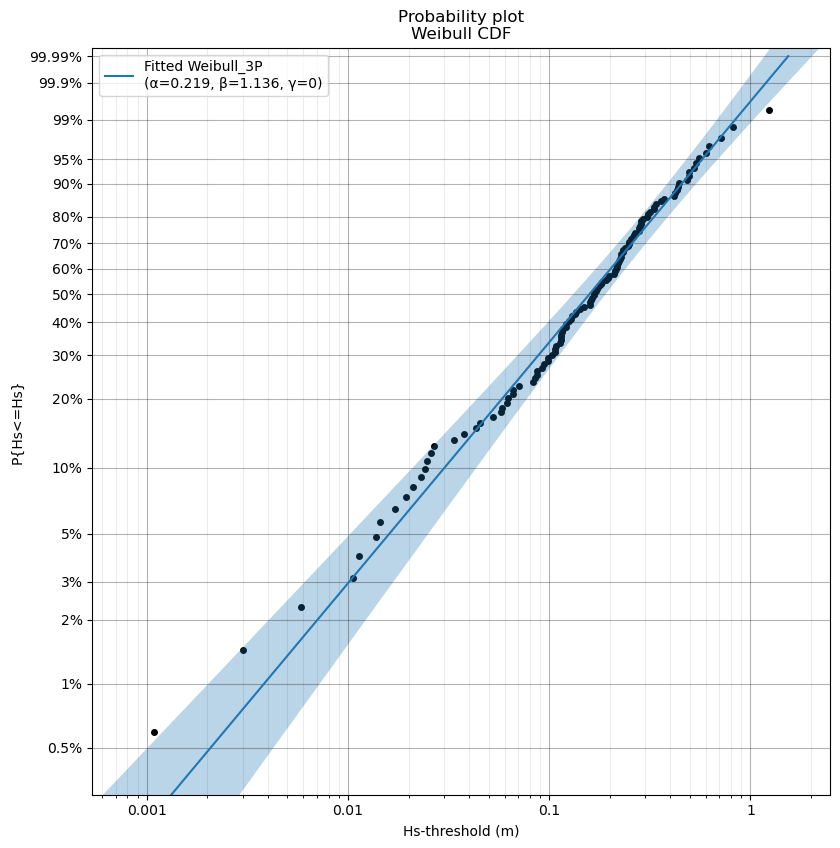

In [11]:
#
#  Weibull 3P fit delivers alpha = scale factor, beta = shape factor & gamma = location factor

waw3 = rf.Fit_Weibull_3P(failures=dfmax)

plt.ylabel('P{Hs<=Hs}')
plt.xlabel('Hs-threshold (m)')
plt.show()


### Fit Gumbel 2P

Results from Fit_Gumbel_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 118/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
       Mu         0.31737        0.028768  0.260986  0.373755
    Sigma        0.293378       0.0157192  0.264132  0.325863 

Goodness of fit    Value
 Log-likelihood -16.9137
           AICc  37.9317
            BIC  43.3687
             AD  12.5215 



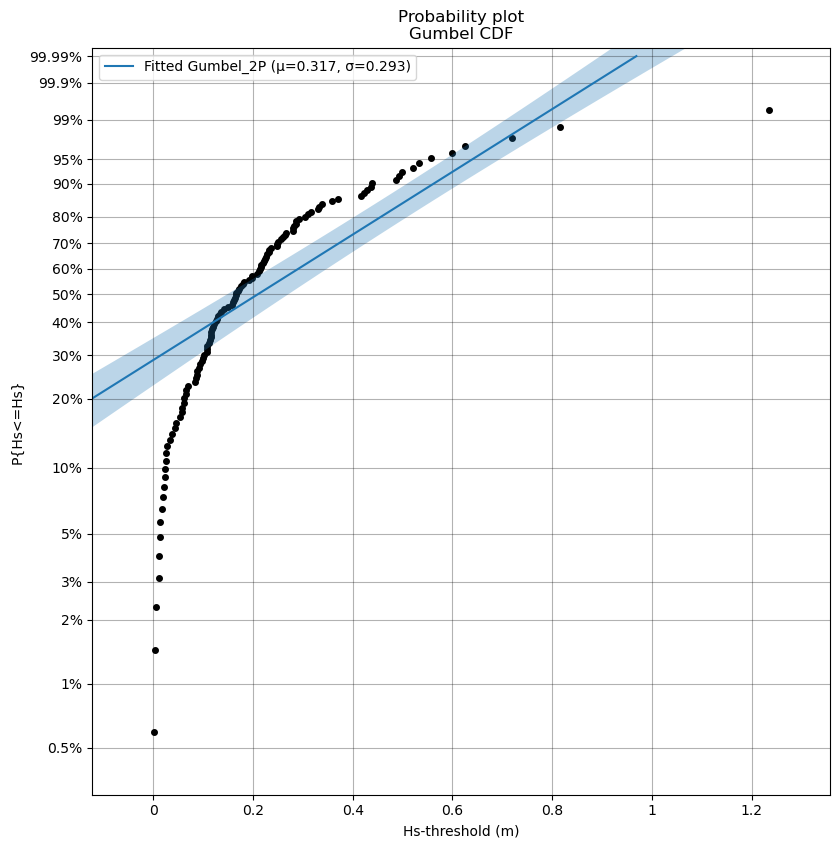

In [12]:
wag = rf.Fit_Gumbel_2P(failures=dfmax)
plt.ylabel('P{Hs<=Hs}')
plt.xlabel('Hs-threshold (m)')
plt.show()

### Fit Exponential 2P

Results from Fit_Exponential_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 118/0 (0% right censored) 

Parameter  Point Estimate  Standard Error    Lower CI    Upper CI
   Lambda         4.80893        0.442697     4.01503      5.7598
 1/Lambda        0.207947        0.019143    0.173617    0.249064
    Gamma     0.000982706               0 0.000982706 0.000982706 

Goodness of fit    Value
 Log-likelihood  67.3159
           AICc -130.527
            BIC  -125.09
             AD  1.32886 



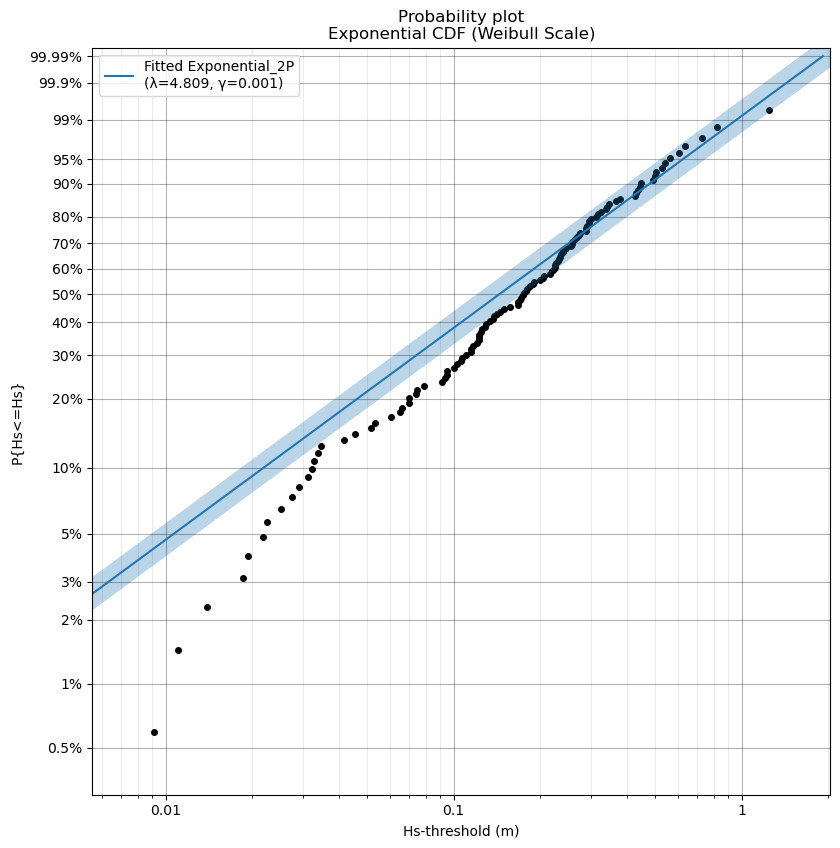

In [13]:
wae = rf.Fit_Exponential_2P(failures=dfmax)
plt.ylabel('P{Hs<=Hs}')
plt.xlabel('Hs-threshold (m)')
plt.show()

## Calculation of 100 year return wave

In [14]:
#
#  Determine return period values
#
#
# define exceedance value for 100 yr return
# 
treturn = 10000
numberyears = 6
numb = len(pot_maxima) / numberyears
prob = 1 - 1/(numb * treturn)
print(prob)

0.9999949152542373


Ensure to add back the threshold tare in the estimated wave height value!

In [15]:
# Weibull 2
X_lower,X_point,X_upper = waw2.distribution.CDF(CI_type='time',CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Weibull2P ',treturn,'Year return value is ',X_point,' (m)')

# Weibull 3
X_lower,X_point,X_upper = waw3.distribution.CDF(CI_type='time',CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Weibull3P ',treturn,'Year return value is ',X_point,' (m)')

# Gumbel
X_lower,X_point,X_upper = wag.distribution.CDF(CI_type='time',CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Gumbel ',treturn,'Year return value is ',X_point,' (m)')

# Exponential
X_lower,X_point,X_upper = wae.distribution.CDF(CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Exponential ',treturn,'Year return value is ',X_point,' (m)')

Weibull2P  10000 Year return value is  4.173929494174519  (m)
Weibull3P  10000 Year return value is  4.173929494174519  (m)
Gumbel  10000 Year return value is  3.250978941231136  (m)
Exponential  10000 Year return value is  4.73569995457156  (m)


## Compare all  distributions

c:\Users\mscha\tudelft-conda\envs\mude-base\Lib\site-packages\reliability\Fitters.py:440: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(


Results from Fit_Everything:
Analysis method: MLE
Failures / Right censored: 118/0 (0% right censored) 

   Distribution    Alpha    Beta       Gamma  Alpha 1   Beta 1  Alpha 2  Beta 2 Proportion 1 DS       Mu    Sigma  Lambda  Log-likelihood     AICc      BIC       AD optimizer
 Exponential_1P                                                                                                   4.78631         66.7596 -131.485 -128.748  1.39608       TNC
     Weibull_2P 0.218649 1.13646                                                                                                   68.262  -132.42 -126.983 0.500522       TNC
       Gamma_2P 0.172105 1.21396                                                                                                  68.0725 -132.041 -126.604 0.581863       TNC
Weibull_Mixture                              0.218762  1.19457    1.234 2499.15     0.990169                                      74.5218 -138.508  -125.19 0.413566  L-BFGS-B
 Exponential_2P     

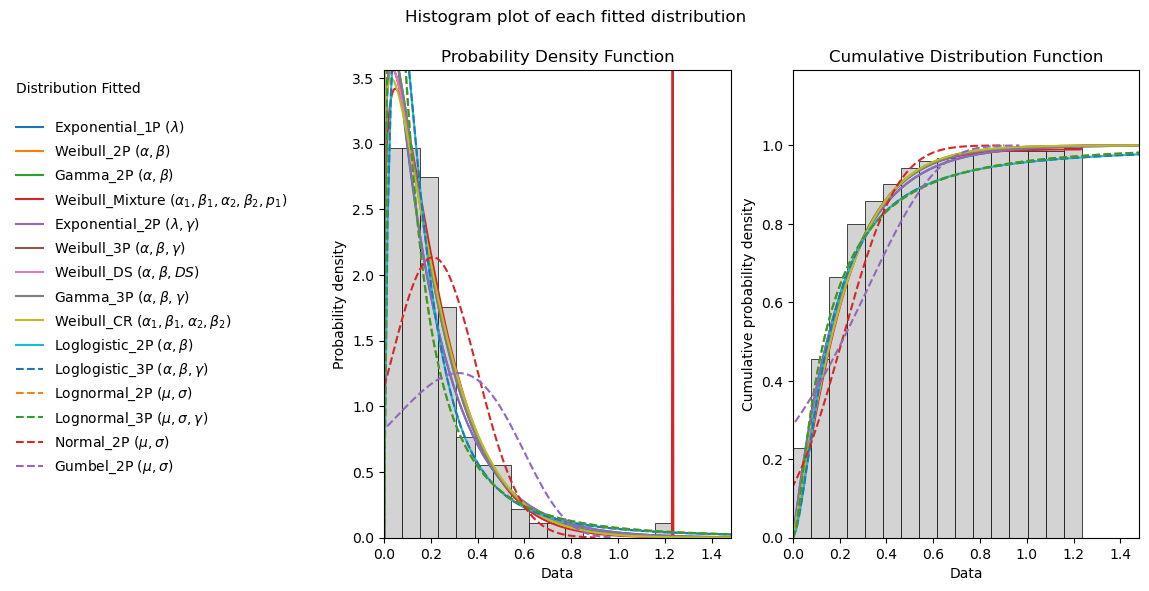

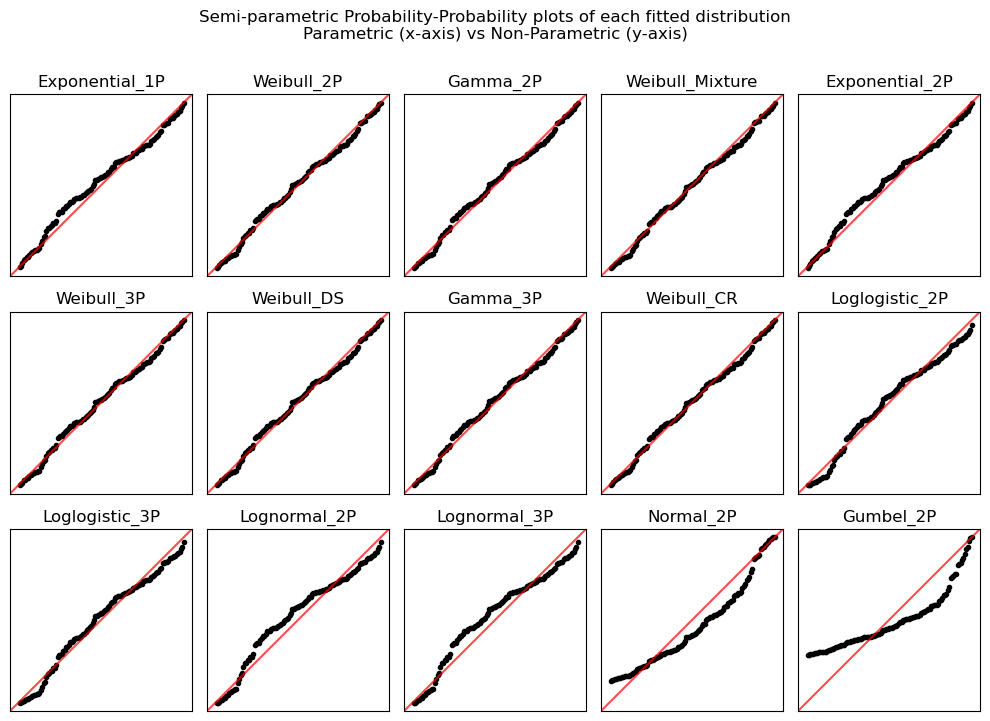

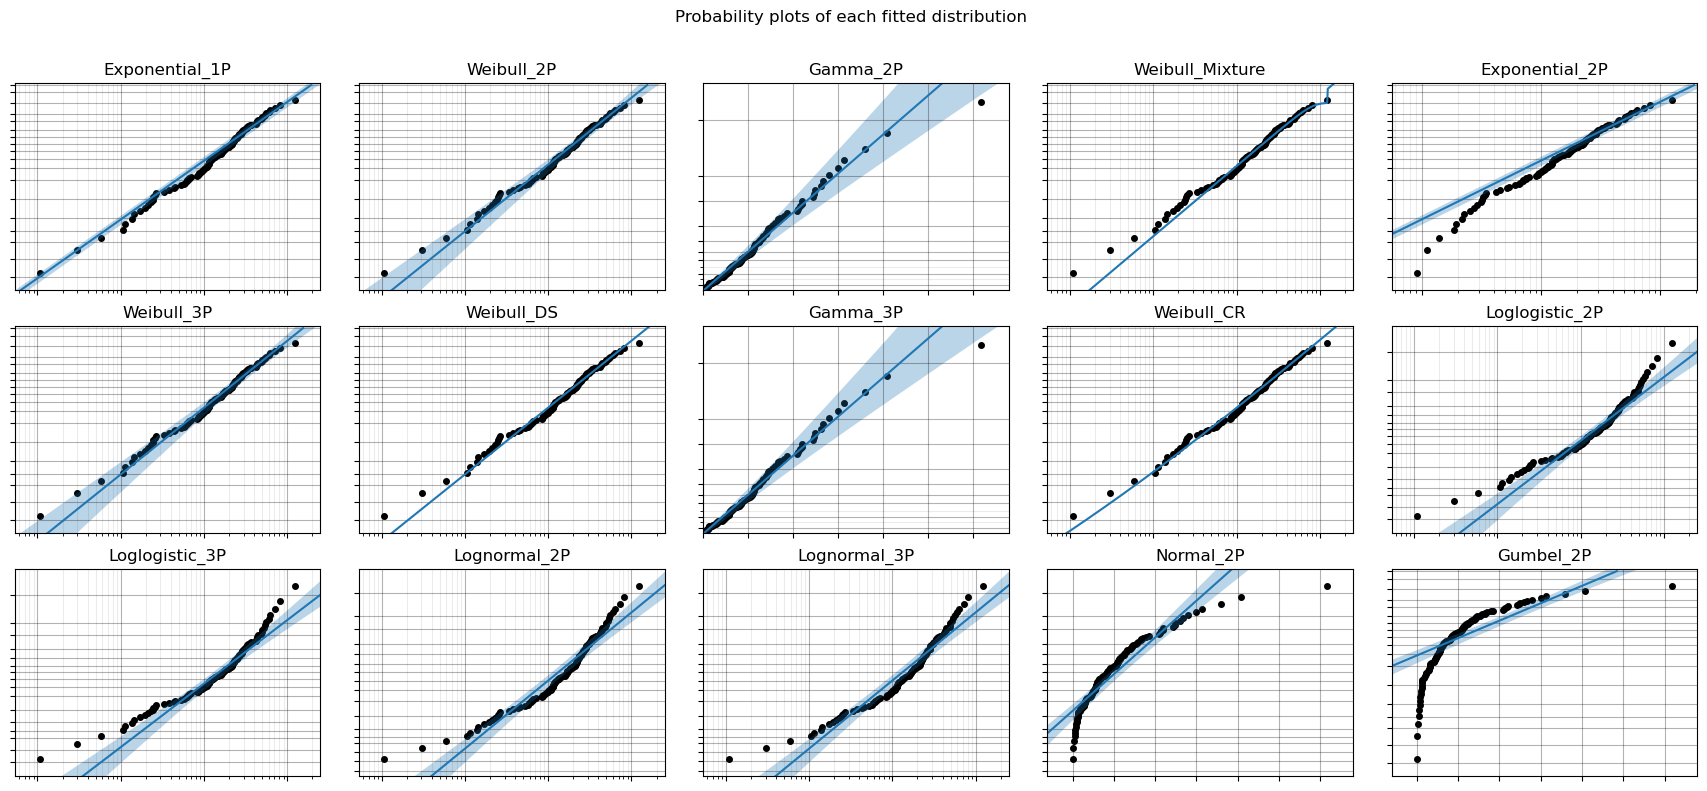

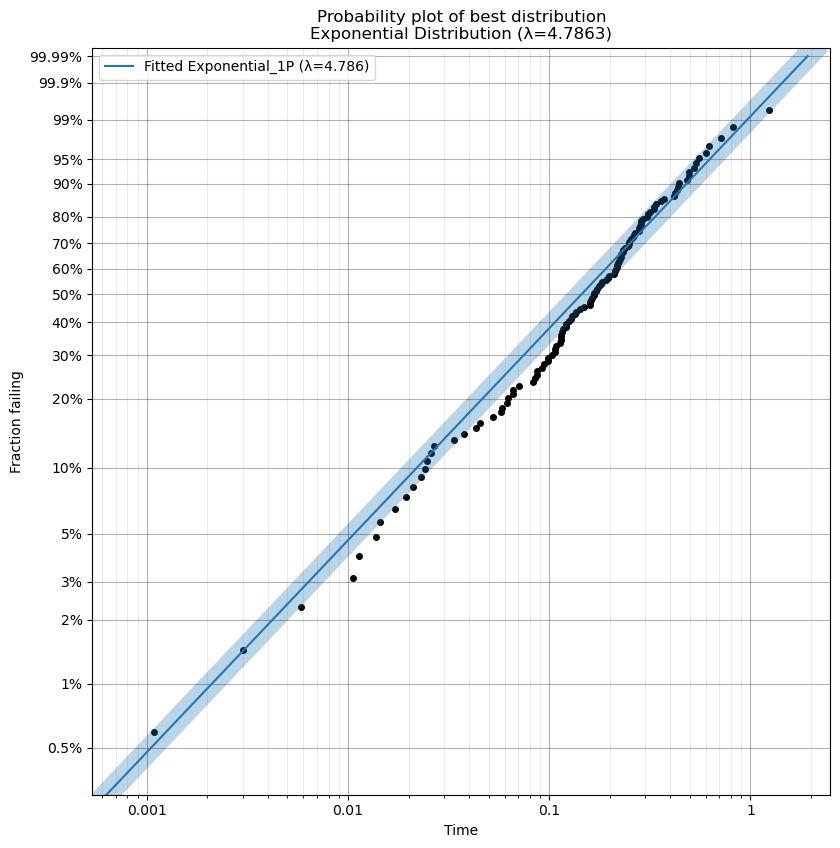

The best fitting distribution was Exponential_1P which had parameters [4.78630621 0.        ]


In [16]:
results = rf.Fit_Everything(failures=dfmax)  # fit all the models
print('The best fitting distribution was', results.best_distribution_name, 'which had parameters', results.best_distribution.parameters)